# Hurricane path prediction


Problem Statement:
Accurately predicting the path of hurricanes is critical for disaster preparedness and risk mitigation.
Traditional forecasting methods often struggle to capture sudden changes in hurricane trajectories.
This project aims to develop a machine learning model to predict hurricane movement in terms of latitude and longitude changes.

Description :
The project uses historical hurricane data to train a Random Forest-based model that predicts the next-step deltas in latitude and longitude.
Key features such as current position, wind speed, pressure, and time-related cyclic variables are used for accurate forecasting.
The model can provide both single-point predictions and batch predictions from uploaded datasets.
An interactive Streamlit app enables users to visualize predictions and download results for further analysis.

In [13]:
import os, json, re, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [14]:
import joblib

RANDOM_STATE = 42
N_JOBS = 1   

def show_df(df, n=5):
    display(df.head(n))

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_r = np.radians(lat1)
    lon1_r = np.radians(lon1)
    lat2_r = np.radians(lat2)
    lon2_r = np.radians(lon2)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat/2.0)**2 + np.cos(lat1_r)*np.cos(lat2_r)*np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

In [15]:
#load dataset
csv_path = "atlantic.csv"   
assert os.path.exists(csv_path), f"CSV not found at {csv_path}. Upload it there or change csv_path."

df_raw = pd.read_csv(csv_path)
print("Loaded CSV shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
show_df(df_raw)


Loaded CSV shape: (49105, 22)
Columns: ['ID', 'Name', 'Date', 'Time', 'Event', 'Status', 'Latitude', 'Longitude', 'Maximum Wind', 'Minimum Pressure', 'Low Wind NE', 'Low Wind SE', 'Low Wind SW', 'Low Wind NW', 'Moderate Wind NE', 'Moderate Wind SE', 'Moderate Wind SW', 'Moderate Wind NW', 'High Wind NE', 'High Wind SE', 'High Wind SW', 'High Wind NW']


,ID,Name,Date,Time,Event,Status,Latitude,Longitude,Maximum Wind,Minimum Pressure,...,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,AL011851,UNNAMED,18510625,0,,HU,28.0N,94.8W,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,AL011851,UNNAMED,18510625,600,,HU,28.0N,95.4W,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,AL011851,UNNAMED,18510625,1200,,HU,28.0N,96.0W,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,AL011851,UNNAMED,18510625,1800,,HU,28.1N,96.5W,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,AL011851,UNNAMED,18510625,2100,L,HU,28.2N,96.8W,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


In [16]:
cols_lower = {c.lower(): c for c in df_raw.columns}
colmap = {}
candidates = {
    'latitude': ['lat', 'latitude', 'lati', 'latitude_deg', 'latt'],
    'longitude': ['lon', 'longitude', 'lng', 'long'],
    'time': ['time', 'datetime', 'date', 'iso_time', 'timestamp', 'date_time'],
    'storm_id': ['id', 'storm_id', 'name', 'stormname', 'cyclone'],
    'wind': ['wind', 'wind_speed', 'wind_knots', 'vmax'],
    'pressure': ['pressure', 'pres', 'mslp']
}
for key, variants in candidates.items():
    for v in variants:
        if v in cols_lower:
            colmap[key] = cols_lower[v]
            break

print("Auto-inferred mapping (check that these are correct):")
for k, v in colmap.items():
    print(f"  {k:10s} -> {v}")
print("\nIf any mapping is incorrect, modify `colmap` below before continuing.")


Auto-inferred mapping (check that these are correct):
  latitude   -> Latitude
  longitude  -> Longitude
  time       -> Time
  storm_id   -> ID

If any mapping is incorrect, modify `colmap` below before continuing.


In [17]:
#Robust parsing of coords and times
df = df_raw.copy()

for k, v in colmap.items():
    df = df.rename(columns={v: k})

#Coordinate parser
def parse_coord(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float, np.number)):
        return float(val)
    s = str(val).strip()
    s_clean = s.replace('°', ' ').replace("'", ' ').replace('"', ' ')
    nums = re.findall(r'[-+]?\d*\.\d+|[-+]?\d+', s_clean)
    if not nums:
        return np.nan
    if len(nums) >= 2:
        deg = float(nums[0]); minute = float(nums[1]); value = deg + minute/60.0
    else:
        value = float(nums[0])
    if re.search(r'[SsWw]', s):
        value = -abs(value)
    return value

if 'latitude' in df.columns:
    df['latitude'] = df['latitude'].apply(parse_coord)
if 'longitude' in df.columns:
    df['longitude'] = df['longitude'].apply(parse_coord)

# Time parsing
if 'time' not in df.columns:
    if 'date' in df_raw.columns and 'time' in df_raw.columns:
        df['time'] = pd.to_datetime(df_raw['date'].astype(str) + ' ' + df_raw['time'].astype(str), errors='coerce')
    elif 'date' in df_raw.columns:
        df['time'] = pd.to_datetime(df_raw['date'], errors='coerce')
else:
    df['time'] = pd.to_datetime(df['time'], errors='coerce')

print("After parsing: null latitudes =", df['latitude'].isna().sum() if 'latitude' in df else 'no lat col',
      "null longitudes =", df['longitude'].isna().sum() if 'longitude' in df else 'no lon col',
      "null times =", df['time'].isna().sum() if 'time' in df else 'no time col')
show_df(df)


After parsing: null latitudes = 0 null longitudes = 0 null times = 0


,storm_id,Name,Date,time,Event,Status,latitude,longitude,Maximum Wind,Minimum Pressure,...,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000000000,,HU,28.0,-94.8,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000000600,,HU,28.0,-95.4,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000001200,,HU,28.0,-96.0,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000001800,,HU,28.1,-96.5,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000002100,L,HU,28.2,-96.8,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


In [18]:
# Ensure storm_id exists 
if 'storm_id' not in df.columns:
    name_cols = [c for c in df.columns if c.lower() in ['name', 'stormname']]
    if name_cols:
        df['storm_id'] = df[name_cols[0]].astype(str) + '_' + df.get('year','').astype(str)
    else:
        df = df.sort_values(by=df.columns[0]).reset_index(drop=True)
        df['storm_id'] = (df.index.to_series().diff().fillna(1) > 10000).cumsum().astype(str)

df = df.dropna(subset=['latitude','longitude','time']).reset_index(drop=True)
df = df.sort_values(by=['storm_id','time']).reset_index(drop=True)
print("After cleaning: shape =", df.shape, ", unique storms =", df['storm_id'].nunique())
show_df(df)


After cleaning: shape = (49105, 22) , unique storms = 1814


,storm_id,Name,Date,time,Event,Status,latitude,longitude,Maximum Wind,Minimum Pressure,...,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000000000,,HU,28.0,-94.8,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,AL011851,UNNAMED,18510626,1970-01-01 00:00:00.000000000,,HU,28.2,-97.0,70,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,AL011851,UNNAMED,18510627,1970-01-01 00:00:00.000000000,,TS,29.0,-99.4,50,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,AL011851,UNNAMED,18510628,1970-01-01 00:00:00.000000000,,TS,31.0,-100.2,40,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,AL011851,UNNAMED,18510625,1970-01-01 00:00:00.000000600,,HU,28.0,-95.4,80,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


In [19]:
#next-position targets and features
df['next_latitude'] = df.groupby('storm_id')['latitude'].shift(-1)
df['next_longitude'] = df.groupby('storm_id')['longitude'].shift(-1)
df['next_time'] = df.groupby('storm_id')['time'].shift(-1)

df = df.dropna(subset=['next_latitude','next_longitude']).reset_index(drop=True)

df['time_diff_hours'] = (df['next_time'] - df['time']).dt.total_seconds() / 3600.0
df = df[df['time_diff_hours'] > 0].reset_index(drop=True)

df['delta_lat'] = df['next_latitude'] - df['latitude']
df['delta_lon'] = df['next_longitude'] - df['longitude']
df['distance_km'] = haversine_km(df['latitude'], df['longitude'], df['next_latitude'], df['next_longitude'])
df['sog_kmh'] = df['distance_km'] / df['time_diff_hours']

df['hour'] = df['time'].dt.hour
df['dayofyear'] = df['time'].dt.dayofyear
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24.0)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24.0)
df['doy_sin'] = np.sin(2*np.pi*df['dayofyear']/365.25)
df['doy_cos'] = np.cos(2*np.pi*df['dayofyear']/365.25)

candidate_features = [
    'latitude','longitude','wind','pressure','time_diff_hours','delta_lat','delta_lon',
    'distance_km','sog_kmh','hour_sin','hour_cos','doy_sin','doy_cos'
]
candidate_features = [c for c in candidate_features if c in df.columns]
print("Candidate features:", candidate_features)
print("Processed shape:", df.shape)
show_df(df[candidate_features + ['next_latitude','next_longitude']])


Candidate features: ['latitude', 'longitude', 'time_diff_hours', 'delta_lat', 'delta_lon', 'distance_km', 'sog_kmh', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
Processed shape: (6139, 36)


,latitude,longitude,time_diff_hours,delta_lat,delta_lon,distance_km,sog_kmh,hour_sin,hour_cos,doy_sin,doy_cos,next_latitude,next_longitude
0,31.0,-100.2,1.666667e-10,-3.0,4.8,571.794368,3.430766e+12,0.0,1.0,0.017202,0.999852,28.0,-95.4
1,29.5,-99.8,1.666667e-10,-1.5,3.8,406.236860,2.437421e+12,0.0,1.0,0.017202,0.999852,28.0,-96.0
2,30.0,-100.0,1.666667e-10,-1.9,3.5,400.446049,2.402676e+12,0.0,1.0,0.017202,0.999852,28.1,-96.5
3,30.5,-100.1,8.333333e-11,-2.3,3.3,409.479249,4.913751e+12,0.0,1.0,0.017202,0.999852,28.2,-96.8
4,41.0,-68.0,1.666667e-10,-20.3,0.0,2257.257011,1.354354e+13,0.0,1.0,0.017202,0.999852,20.7,-68.0


Number of storms: 1783
Observations per storm (describe):
count    1783.000000
mean        3.443073
std         0.860654
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max        11.000000
dtype: float64


,latitude,longitude,time_diff_hours,delta_lat,delta_lon,distance_km,sog_kmh,hour_sin,hour_cos,doy_sin,doy_cos
count,6139.000000,6139.000000,6.139000e+03,6139.000000,6139.000000,6139.000000,6.139000e+03,6139.0,6139.0,6.139000e+03,6.139000e+03
mean,33.731113,-66.556768,1.477094e-10,-11.821046,-0.112478,2050.736715,1.672857e+13,0.0,1.0,1.720158e-02,9.998520e-01
std,11.554952,23.748167,4.091994e-11,11.534281,20.316496,1549.814045,2.295549e+13,0.0,0.0,1.720986e-15,4.097057e-14
min,8.500000,-359.100000,2.777778e-12,-59.400000,-135.300000,0.000000,0.000000e+00,0.0,1.0,1.720158e-02,9.998520e-01
25%,25.600000,-85.400000,1.666667e-10,-18.200000,-9.200000,800.864731,5.529773e+12,0.0,1.0,1.720158e-02,9.998520e-01
50%,33.000000,-68.800000,1.666667e-10,-8.700000,0.700000,1712.140121,1.206152e+13,0.0,1.0,1.720158e-02,9.998520e-01
75%,41.500000,-51.100000,1.666667e-10,-2.900000,9.000000,3012.109134,2.076364e+13,0.0,1.0,1.720158e-02,9.998520e-01
max,81.000000,48.000000,3.333333e-10,20.900000,332.100000,8550.584423,4.330591e+14,0.0,1.0,1.720158e-02,9.998520e-01


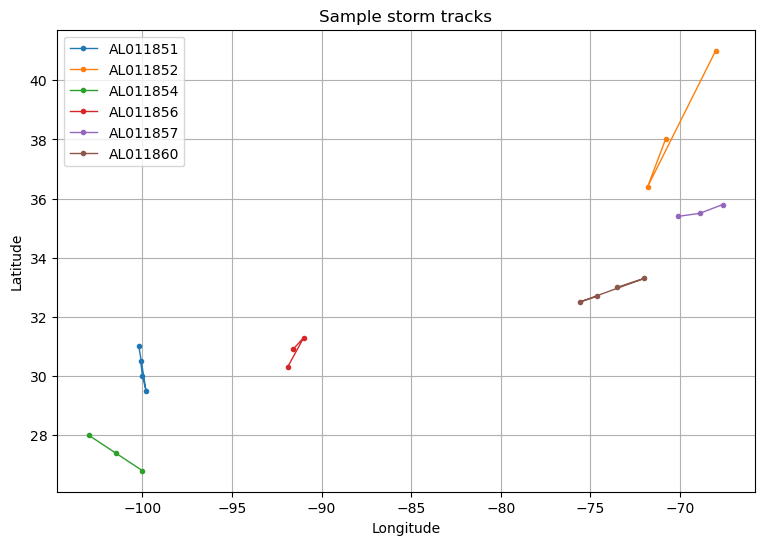

<Figure size 1000x500 with 0 Axes>

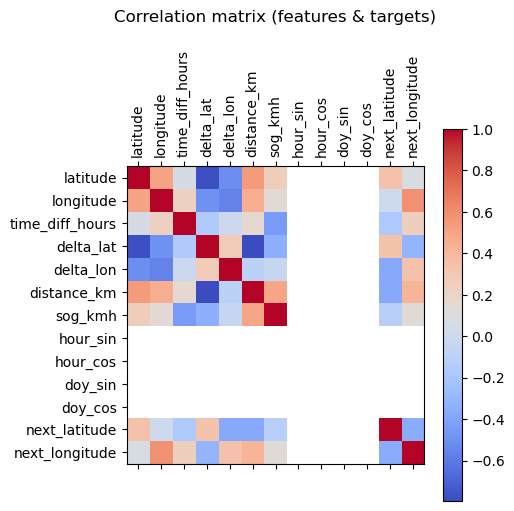

In [20]:
#EDA - statistics and plots
print("Number of storms:", df['storm_id'].nunique())
print("Observations per storm (describe):")
print(df.groupby('storm_id').size().describe())

display(df[candidate_features].describe())

sample_storms = df['storm_id'].unique()[:6]
plt.figure(figsize=(9,6))
for sid in sample_storms:
    s = df[df['storm_id']==sid]
    plt.plot(s['longitude'], s['latitude'], marker='o', linewidth=1, markersize=3, label=str(sid))
plt.xlabel('Longitude'); plt.ylabel('Latitude'); plt.title('Sample storm tracks'); plt.legend(); plt.grid(True); plt.show()

# correlation matrix
num_cols = candidate_features + ['next_latitude', 'next_longitude']
corr = df[num_cols].corr()

plt.figure(figsize=(10,5))
plt.matshow(corr.values, cmap='coolwarm') 
plt.title("Correlation matrix (features & targets)", pad=20)
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.show()


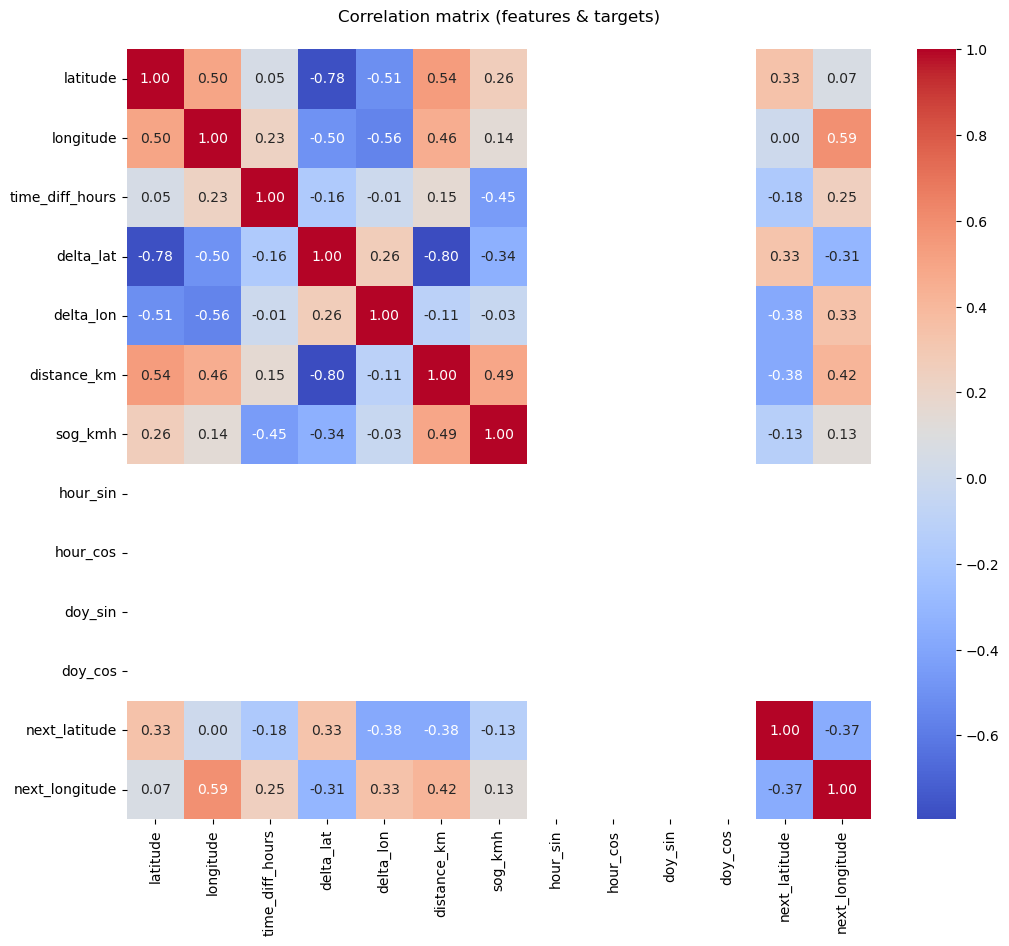

In [21]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            xticklabels=num_cols, yticklabels=num_cols, mask=corr.isnull())
plt.title("Correlation matrix (features & targets)", pad=20)
plt.show()


In [22]:
df[num_cols].isna().sum()
df[num_cols].nunique()


latitude            542
longitude           926
time_diff_hours      74
delta_lat          1240
delta_lon          1836
distance_km        6123
sog_kmh            6126
hour_sin              1
hour_cos              1
doy_sin               1
doy_cos               1
next_latitude       358
next_longitude      804
dtype: int64

In [23]:
#prepare model X and y & group-wise split
df_model = df.dropna(subset=candidate_features + ['next_latitude','next_longitude']).reset_index(drop=True)
X = df_model[candidate_features].copy()
y_abs = df_model[['next_latitude','next_longitude']].copy()
y_offset = pd.DataFrame(y_abs.values - df_model[['latitude','longitude']].values, columns=['dlat_target','dlon_target'])

print("Final modeling dataset shape:", X.shape)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, groups=df_model['storm_id']))
X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y_offset.iloc[train_idx].reset_index(drop=True), y_offset.iloc[test_idx].reset_index(drop=True)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Final modeling dataset shape: (6139, 11)
Train shape: (4921, 11) Test shape: (1218, 11)


In [24]:
#baseline comparison with quick CV
def cv_rmse(model, X, y, cv):
    rmses = []
    for train_i, val_i in cv.split(X):
        model.fit(X.iloc[train_i], y.iloc[train_i])
        pred = model.predict(X.iloc[val_i])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[val_i], pred)))
    return float(np.mean(rmses)), float(np.std(rmses))

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

models = {
    'RandomForest': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=N_JOBS)),
    'GradientBoosting': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE))
}

comparison = {}
for name, m in models.items():
    print("Running CV for", name)
    mean_rmse, std_rmse = cv_rmse(m, X_train, y_train, cv)
    comparison[name] = (mean_rmse, std_rmse)
    print(f"  {name} CV RMSE: {mean_rmse:.6f} +/- {std_rmse:.6f} (degrees)")

best_name = min(comparison, key=lambda k: comparison[k][0])
print("Selected base model:", best_name)


Running CV for RandomForest
  RandomForest CV RMSE: 1.206488 +/- 0.783392 (degrees)
Running CV for GradientBoosting
  GradientBoosting CV RMSE: 0.368334 +/- 0.116940 (degrees)
Selected base model: GradientBoosting


Feature importances (avg):


delta_lat          0.500485
delta_lon          0.479778
longitude          0.019213
distance_km        0.000256
latitude           0.000234
sog_kmh            0.000028
time_diff_hours    0.000004
hour_sin           0.000000
hour_cos           0.000000
doy_sin            0.000000
doy_cos            0.000000
dtype: float64

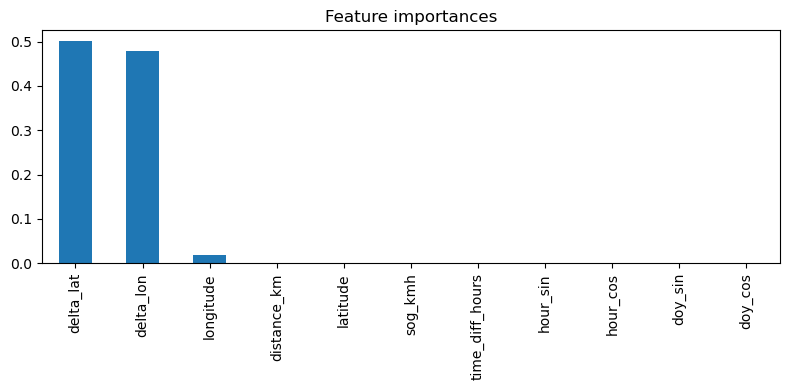

In [25]:
#feature importance from a quick-fit RF and optional selection
rf_quick = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=N_JOBS))
rf_quick.fit(X_train, y_train)

def avg_feature_importances(multi_estimator):
    imps = []
    if hasattr(multi_estimator, 'estimators_'):
        for est in multi_estimator.estimators_:
            if hasattr(est, 'feature_importances_'):
                imps.append(est.feature_importances_)
    if len(imps) == 0:
        return None
    return np.mean(imps, axis=0)

imps = avg_feature_importances(rf_quick)
if imps is not None:
    feat_imp = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)
    print("Feature importances (avg):")
    display(feat_imp)
    plt.figure(figsize=(8,4))
    feat_imp.plot(kind='bar')
    plt.title('Feature importances'); plt.tight_layout(); plt.show()
else:
    print("Feature importances not available.")

TOP_K = None  
if TOP_K is not None and imps is not None:
    top_features = feat_imp.index[:TOP_K].tolist()
    print("Selecting top features:", top_features)
    X_train_sel = X_train[top_features].copy()
    X_test_sel = X_test[top_features].copy()
else:
    X_train_sel = X_train.copy()
    X_test_sel = X_test.copy()
    top_features = X_train_sel.columns.tolist()


In [26]:
#the top features from train/test sets
X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]


In [27]:
#grid search on a sample - tune chosen model
if best_name == 'RandomForest':
    base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS)
    param_grid = {
        'estimator__n_estimators': [100, 200],
        'estimator__max_depth': [10, 20, None],
        'estimator__min_samples_split': [2, 5]
    }
else:
    base = GradientBoostingRegressor(random_state=RANDOM_STATE)
    param_grid = {
        'estimator__n_estimators': [100, 200],
        'estimator__max_depth': [3, 5],
        'estimator__learning_rate': [0.05, 0.1]
    }

multi = MultiOutputRegressor(base)
grid = GridSearchCV(multi, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=1, verbose=2)

SAMPLE_MAX = 4000
sample_size = min(SAMPLE_MAX, X_train_sel.shape[0])
sample_idx = np.random.choice(range(X_train_sel.shape[0]), size=sample_size, replace=False)
print("GridSearch fitting on sample size:", sample_size)
grid.fit(X_train_sel.iloc[sample_idx], y_train.iloc[sample_idx])

print("Best params:", grid.best_params_)
best_estimator = grid.best_estimator_

# Fit best estimator on full training data
best_estimator.fit(X_train_sel, y_train)


GridSearch fitting on sample size: 4000
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END estimator__learning_rate=0.05, estimator__max_depth=3, estimator__n_estimators=100; total time=   2.5s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=3, estimator__n_estimators=100; total time=   3.2s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=3, estimator__n_estimators=100; total time=   3.4s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=3, estimator__n_estimators=200; total time=   6.1s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=3, estimator__n_estimators=200; total time=   7.1s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=3, estimator__n_estimators=200; total time=   7.0s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=5, estimator__n_estimators=100; total time=   5.5s
[CV] END estimator__learning_rate=0.05, estimator__max_depth=5, estimator__n_estimators=100; total time=   5.1s
[CV]

MultiOutputRegressor(estimator=GradientBoostingRegressor(learning_rate=0.05,
                                                         n_estimators=200,
                                                         random_state=42))

--- Test set evaluation ---
Degree RMSE: 0.244472 degrees
Degree MAE: 0.074682 degrees
Mean error: 13.57 km, median: 8.83 km
% within 50 km: 98.11%, within 100 km: 99.34%
R2 (dlat): 0.9999744744477336
R2 (dlon): 0.9997276829146768


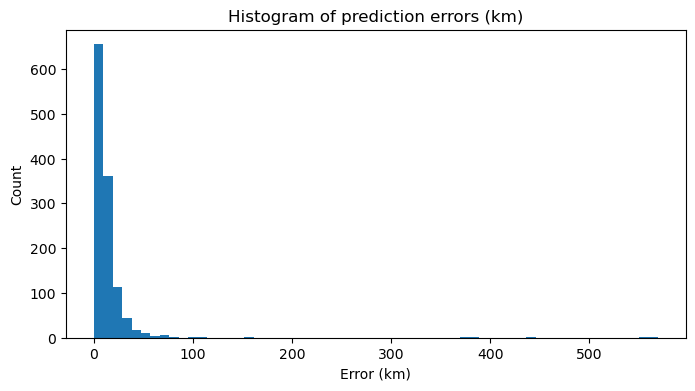

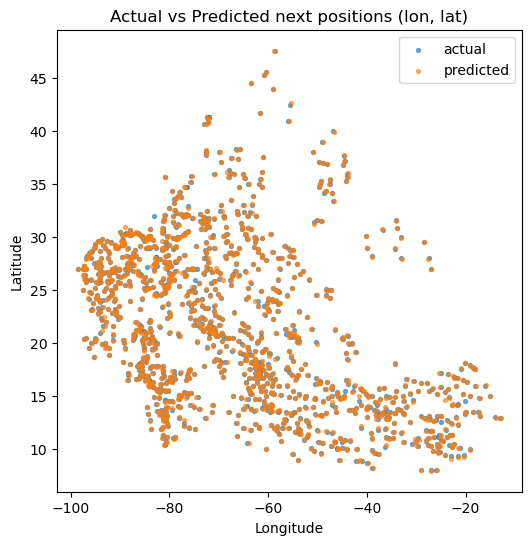

In [28]:
#evaluation on test set
pred_offset = best_estimator.predict(X_test_sel)
pred_lat = X_test['latitude'].values + pred_offset[:,0]
pred_lon = X_test['longitude'].values + pred_offset[:,1]
actual_lat = X_test['latitude'].values + y_test['dlat_target'].values
actual_lon = X_test['longitude'].values + y_test['dlon_target'].values

# degree-space error
deg_rmse = np.sqrt(mean_squared_error(np.column_stack([actual_lat, actual_lon]), np.column_stack([pred_lat, pred_lon])))
deg_mae = mean_absolute_error(np.column_stack([actual_lat, actual_lon]), np.column_stack([pred_lat, pred_lon]))

# haversine km errors
km_errors = haversine_km(actual_lat, actual_lon, pred_lat, pred_lon)
mean_km = np.mean(km_errors)
median_km = np.median(km_errors)
within_50 = np.mean(km_errors <= 50.0) * 100.0
within_100 = np.mean(km_errors <= 100.0) * 100.0

print("--- Test set evaluation ---")
print(f"Degree RMSE: {deg_rmse:.6f} degrees")
print(f"Degree MAE: {deg_mae:.6f} degrees")
print(f"Mean error: {mean_km:.2f} km, median: {median_km:.2f} km")
print(f"% within 50 km: {within_50:.2f}%, within 100 km: {within_100:.2f}%")
print("R2 (dlat):", r2_score(y_test.iloc[:,0], pred_offset[:,0]))
print("R2 (dlon):", r2_score(y_test.iloc[:,1], pred_offset[:,1]))

# Plot error distribution
plt.figure(figsize=(8,4))
plt.hist(km_errors, bins=60)
plt.xlabel('Error (km)'); plt.ylabel('Count'); plt.title('Histogram of prediction errors (km)'); plt.show()

# scatter actual vs predicted next-lat
plt.figure(figsize=(6,6))
plt.scatter(actual_lon, actual_lat, s=8, alpha=0.6, label='actual')
plt.scatter(pred_lon, pred_lat, s=8, alpha=0.6, label='predicted')
plt.legend(); plt.title('Actual vs Predicted next positions (lon, lat)'); plt.xlabel('Longitude'); plt.ylabel('Latitude'); plt.show()


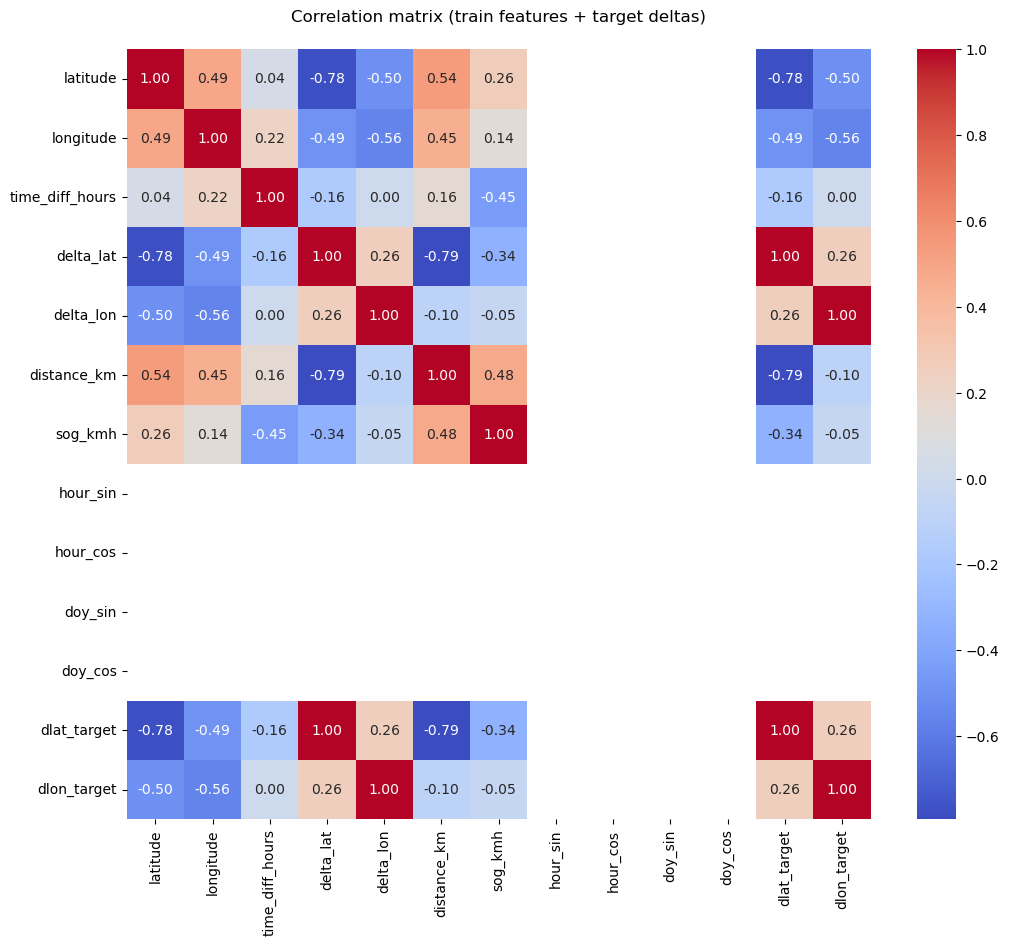

delta_lat          5.001909e-01
delta_lon          4.822470e-01
longitude          1.457555e-02
sog_kmh            2.544646e-03
latitude           2.398234e-04
distance_km        2.020764e-04
time_diff_hours    8.454689e-09
hour_sin           0.000000e+00
hour_cos           0.000000e+00
doy_sin            0.000000e+00
doy_cos            0.000000e+00
dtype: float64

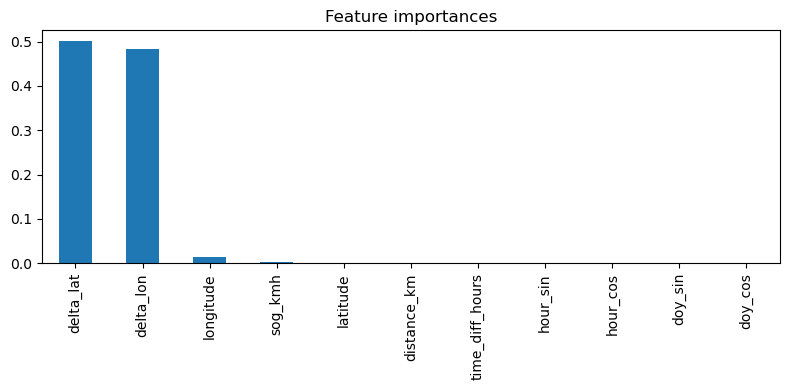

In [29]:
#correlation between features and target deltas
corr_ft = pd.concat([X_train_sel.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_ft, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            xticklabels=corr_ft.columns, yticklabels=corr_ft.columns)
plt.title("Correlation matrix (train features + target deltas)", pad=20)
plt.show()

try:
    imps = None
    if hasattr(best_estimator.estimator, 'feature_importances_'):
        imps = best_estimator.estimator.feature_importances_
    else:
        imps_all = [getattr(est, 'feature_importances_', None) for est in best_estimator.estimators_]
        imps_all = [x for x in imps_all if x is not None]
        if imps_all:
            imps = np.mean(imps_all, axis=0)
    if imps is not None:
        feat_imp = pd.Series(imps, index=X_train_sel.columns).sort_values(ascending=False)
        display(feat_imp)
        plt.figure(figsize=(8,4)); feat_imp.plot(kind='bar'); plt.title('Feature importances'); plt.tight_layout(); plt.show()
    else:
        print("No feature importances available for this estimator.")
except Exception as e:
    print("Exception computing feature importances:", e)


In [31]:
#save the trained model and performance metadata
model_path = "final_hurricane_model.pkl"
metadata_path = "model_metadata.json"
joblib.dump({'model': best_estimator, 'features': top_features}, model_path)

meta = {
    'deg_rmse': float(deg_rmse),
    'deg_mae': float(deg_mae),
    'mean_km_error': float(mean_km),
    'median_km_error': float(median_km),
    'within_50km_pct': float(within_50),
    'within_100km_pct': float(within_100),
    'model_type': best_name
}
with open(metadata_path, 'w') as f:
    json.dump(meta, f, indent=2)

print("Saved model to:", model_path)
print("Saved metadata to:", metadata_path)


Saved model to: final_hurricane_model.pkl
Saved metadata to: model_metadata.json


In [33]:
import joblib
import json

# Paths to save files
model_path = "final_hurricane_model.pkl"
metadata_path = "model_metadata.json"

# Save the trained model
joblib.dump(best_estimator, model_path)
meta = {
    'features': top_features,  
    'deg_rmse': float(deg_rmse),
    'deg_mae': float(deg_mae),
    'model_type': "RandomForest"
}

with open(metadata_path, 'w') as f:
    json.dump(meta, f, indent=4)

print("✅ Best estimator and metadata saved")


✅ Best estimator and metadata saved


In [34]:
# Load model
loaded_model = joblib.load(model_path)

with open(metadata_path, 'r') as f:
    meta = json.load(f)

loaded_features = meta['features']

print("✅ Model loaded")
print("Features:", loaded_features)
print("Model type:", meta['model_type'])


✅ Model loaded
Features: ['latitude', 'longitude', 'time_diff_hours', 'delta_lat', 'delta_lon', 'distance_km', 'sog_kmh', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
Model type: RandomForest


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict on test set
y_pred = loaded_model.predict(X_test[loaded_features])

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
deg_rmse_final = np.sqrt(mse)
deg_mae_final = mean_absolute_error(y_test, y_pred)

print(f"Final Test RMSE (degrees): {deg_rmse_final:.4f}")
print(f"Final Test MAE (degrees): {deg_mae_final:.4f}")

km_rmse_final = deg_rmse_final * 111
km_mae_final = deg_mae_final * 111
print(f"Final Test RMSE: {km_rmse_final:.2f} km")
print(f"Final Test MAE: {km_mae_final:.2f} km")


Final Test RMSE (degrees): 0.2445
Final Test MAE (degrees): 0.0747
Final Test RMSE: 27.14 km
Final Test MAE: 8.29 km


In [36]:
# Take first test sample
sample = X_test.iloc[[0]][loaded_features]

pred = loaded_model.predict(sample)

print("Input features:", sample.to_dict(orient="records")[0])
print("Predicted Δlat, Δlon:", pred[0])
print("True Δlat, Δlon:", y_test.iloc[0].values)


Input features: {'latitude': 29.1, 'longitude': -96.3, 'time_diff_hours': 1.6666666666666666e-10, 'delta_lat': -2.3000000000000007, 'delta_lon': 9.0, 'distance_km': 919.9766861992937, 'sog_kmh': 5519860117195.763, 'hour_sin': 0.0, 'hour_cos': 1.0, 'doy_sin': 0.017201575418260506, 'doy_cos': 0.9998520419557735}
Predicted Δlat, Δlon: [-2.24989498  8.99244427]
True Δlat, Δlon: [-2.3  9. ]


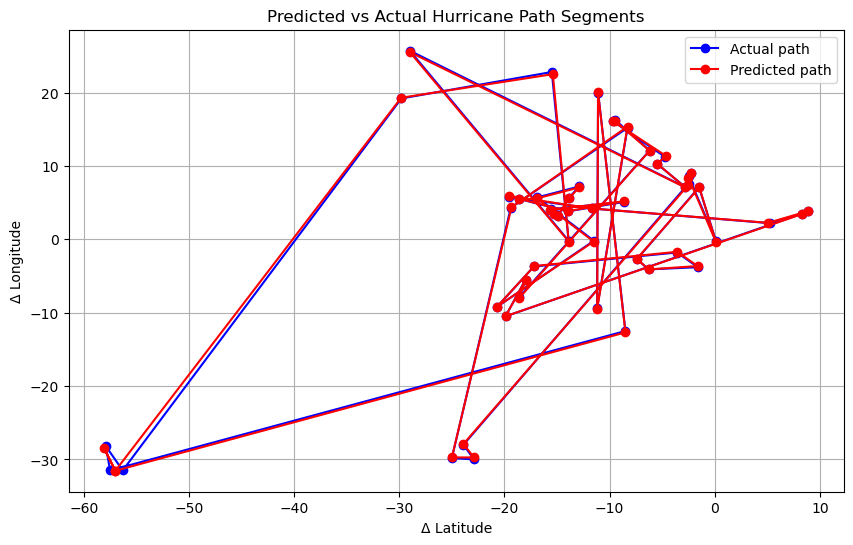

In [37]:
import matplotlib.pyplot as plt

N = min(50, X_test.shape[0])
true_path = y_test[:N].reset_index(drop=True)
pred_path = y_pred[:N]

plt.figure(figsize=(10,6))
plt.plot(true_path.iloc[:,0], true_path.iloc[:,1], 'bo-', label="Actual path")
plt.plot(pred_path[:,0], pred_path[:,1], 'ro-', label="Predicted path")
plt.xlabel("Δ Latitude")
plt.ylabel("Δ Longitude")
plt.title("Predicted vs Actual Hurricane Path Segments")
plt.legend()
plt.grid(True)
plt.show()
